# <u>Simple Linear Regression (one feature)</u>

## Topics

* [1. Problem setup](#setup)
* [2. Assumptions for Simple Linea Regression](#assume)
* [3. Core Minimization problem (OLS)](#min)
* [4. Model Quality](#min)
* [4. Statistical Inference](#stats)
* [5. Gradient Descent](#gd)
* [6. Batch Gradient Descent](#gd)
* [7. Stochastic Gradient Descent (SGD)](#sgd)
* [8. Implementation](#imple)
* [9. Scikit-Learn Implementation](#scikit)
* [10. Limitations](#limits)
    



<a class="anchor" id="setup"></a>
## 1. Problem setup

In this notebook, I will build a **Simple Linear Regression model** to predict house prices based on the **size of a house**.

The goal is to learn the relationship between **house size (input feature)** and **house price (target variable)** using a linear model.

### Variables

* **Size** — Size of the house (input feature)
* **Price** — Price of the house (target variable)

In real life the model looks like this:

$$
\text{Price}_i = \beta_0 + \beta_1 \cdot \text{Size}_i + \varepsilon_i \hspace{2 mm} \text{ for each house }i
$$

where $\varepsilon$ are error terms for each house distorting the true relationship between Price and Size.

The model will learn a relationship of the form:

$$
\widehat{\text{Price}_i} = \hat{\beta_0} + \hat{\beta_1} \cdot \text{Size}_i 
$$

where **$\hat{\beta_1}$** is the estimated slope,**$\hat{\beta_0}$**  the estimated intercept and $\widehat{\text{Price}_i}$ the predicted *Price* for a new houses based on their *Size* .




In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd 
import scipy.stats as stats

<a class="anchor" id="assume"></a>
## 2. Assumptions for Simple Linear Regression

| Assumption               | Description                                                                 | Affects $\hat{\beta_0}$ and $\hat{\beta_1}$ | Affects Statistical Inference | Verification                          |
|--------------------------|-----------------------------------------------------------------------------|---------------------------|--------------------------------------|-----------------------------------------------|
| Linearity               | Relationship between X (aka Size) and Y (aka Price) is linear.                                     | &#9989;                       | &#9989;                                  | Residuals vs. Fitted Plot, Scatterplot of X (aka Size) and Y (aka Price)                    |
| Independent errors            | Errors are independent from each other.                                     | &#10060;                        | &#9989;                                  | Residuals vs. Order Plot |
| Homoscedasticity        | Constant variance of errors across values of X.                              | &#10060;                         | &#9989;                                  | Residuals vs. Fitted Plot                     |
| Normality of Errors  $\varepsilon_i \sim \mathcal{N}(\text{mean},\text{variance})$     | Residuals follow a normal distribution.                                      | &#10060;                          | &#9989;                                  | Q–Q Plot of residuals, Histogram of Residuals                         |
| No Extreme Outliers     | Influential observations should not dominate the model. | &#9989;            | &#9989;                                  | Boxplot of X and Y, Residuals vs. Fitted Plot |



### Linearity

Simple linear regression assumes linearity because it tries to fit a straight line. If the relationship between the feature and target is not roughly linear, the line cannot model it well. Linear means that if one variable increases the other should also increase or decrease. This kind of elationship should be visible when plotting the data.

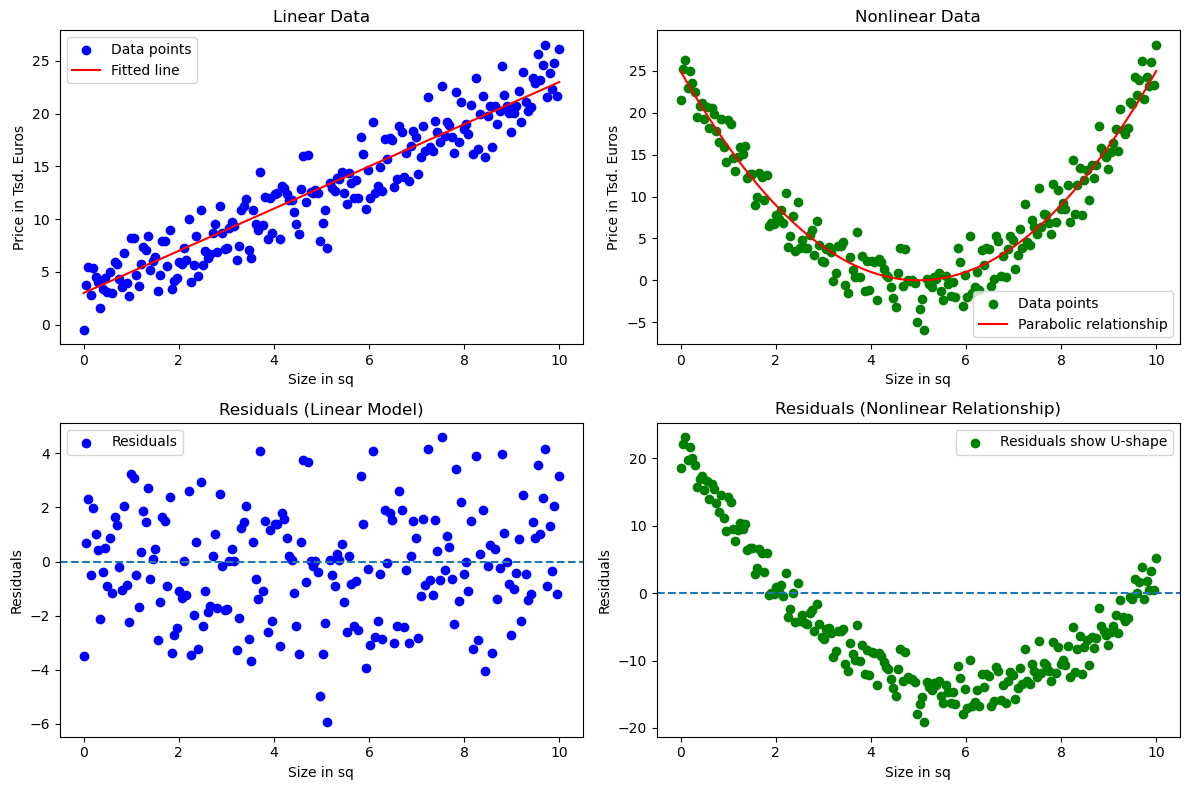

In [256]:
np.random.seed(100)  # Seed for reproducibility of random numbers

n = 200 # number of houses

size = np.linspace(0, 10, n) # house sizes in square meters

# Linear Data
beta_0, beta_1 = 3, 2 # true coefficients
error = np.random.normal(0, 2, n) # error terms to distort true relationship
true_price_linear = beta_0 + beta_1 * size # true relationship between Price and Size
price_linear = true_price_linear + error # distorted relationship between Price and Size


# Nonlinear Data 
true_price_nonlinear = (size - 5)**2 # true relationship between Price and Size
price_nonlinear = true_price_nonlinear + error # distorted relationship between Price and Size


# Plotting
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Linear data plot
axes[0,0].scatter(size, price_linear, color='blue', label='Data points')
axes[0,0].plot(size, true_price_linear, color='red', label='Fitted line')
axes[0,0].set_title("Linear Data")
axes[0,0].set_xlabel("Size in sq")
axes[0,0].set_ylabel("Price in Tsd. Euros")
axes[0,0].legend()

# Nonlinear data plot
axes[0,1].scatter(size, price_nonlinear, color='green', label='Data points')
axes[0,1].plot(size, true_price_nonlinear, color='red', label='Parabolic relationship')
axes[0,1].set_title("Nonlinear Data")
axes[0,1].set_xlabel("Size in sq")
axes[0,1].set_ylabel("Price in Tsd. Euros")
axes[0,1].legend()


# Residuals
res_linear = price_linear - true_price_linear
res_nonlinear = price_nonlinear - true_price_linear

# Plot Residuals of linear model
axes[1,0].scatter(size, res_linear, color="blue", label="Residuals")
axes[1,0].axhline(0, linestyle="--")
axes[1,0].set_title("Residuals (Linear Model)")
axes[1,0].set_xlabel("Size in sq")
axes[1,0].set_ylabel("Residuals")
axes[1,0].legend()

# Plot Residuals of non-linear model
axes[1,1].scatter(size, res_nonlinear, color="green", label="Residuals show U-shape")
axes[1,1].axhline(0, linestyle="--")
axes[1,1].set_title("Residuals (Nonlinear Relationship)")
axes[1,1].set_xlabel("Size in sq")
axes[1,1].set_ylabel("Residuals")
axes[1,1].legend()


plt.tight_layout()
plt.show()

### Independent errors

Dependent errors occur when one data point is influenced by or correlated with another. Mathematically this means $\mathrm{Cov}(\varepsilon_i, \varepsilon_j) \neq 0$ for $i \neq j$.

Example:
- House prices in the same neighborhood that trend together
- Stock prices over consecutive days (time series data)


How It Affects the Model:

- Statistical inference becomes unreliable

    - Standard errors, t-tests, p-values, and confidence intervals assume independence.

Diagnostic:
- Residual vs Orders Plot


Covariance of consecutive independent errors (closer to 0): 0.1348
Covariance of consecutive dependent errors: 1.8722


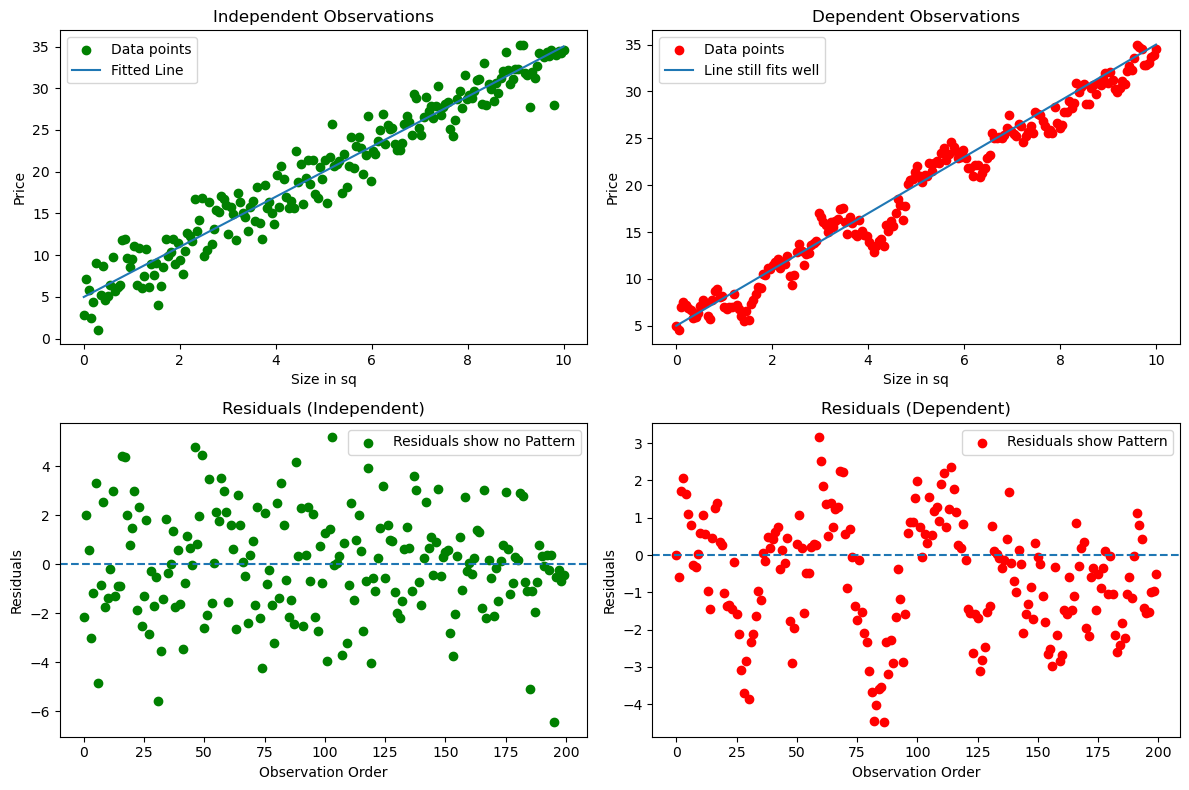

In [ ]:
np.random.seed(123) # for reproducibility of random numbers

n = 200 # number of houses

size = np.linspace(0, 10, n) # house sizes in sq

beta_0, beta_1 = 5, 3 # true coefficients

price_true = beta_0 + beta_1 * size # true relationship between price and size

errors_ind = np.random.normal(0, 2, n) # Independent errors

price_ind = price_true + errors_ind # distorted relationship between price and size using independent errors

# Dependent errors by creating autocorrelated errors (AR(1))
rho = 0.8
errors_dep = np.zeros(n)
noise = np.random.normal(0, 1, n)

for t in range(1, n):
    errors_dep[t] = rho * errors_dep[t-1] + noise[t] # next error depends on previous one with formula error_i = p*error_i-1 + noise


price_dep = price_true + errors_dep # distorted relationship between price and size using dependent errors


# Covariance between consecutive errors
cov_ind = np.cov(errors_ind[:-1], errors_ind[1:])[0, 1]
cov_dep = np.cov(errors_dep[:-1], errors_dep[1:])[0, 1]

print(f"Covariance of consecutive independent errors (closer to 0): {cov_ind:.4f}")
print(f"Covariance of consecutive dependent errors: {cov_dep:.4f}")

# Plot 
fig, axes = plt.subplots(2, 2, figsize=(12,8))

# Independent data
axes[0,0].scatter(size, price_ind,color="green",label="Data points")
axes[0,0].plot(size, price_true,label="Fitted Line")
axes[0,0].set_title("Independent Observations")
axes[0,0].set_ylabel("Price")
axes[0,0].set_xlabel("Size in sq")
axes[0,0].legend()

# Dependent data
axes[0,1].scatter(size, price_dep,color="red",label="Data points")
axes[0,1].plot(size, price_true,label="Line still fits well")
axes[0,1].set_title("Dependent Observations")
axes[0,1].set_ylabel("Price")
axes[0,1].set_xlabel("Size in sq")
axes[0,1].legend()

# Residuals
res_ind = price_ind - price_true
res_dep = price_dep - price_true

# Independent residuals
axes[1,0].scatter(range(n), res_ind,color="green",label="Residuals show no Pattern")
axes[1,0].axhline(0, linestyle="--")
axes[1,0].set_title("Residuals (Independent)")
axes[1,0].set_ylabel("Residuals")
axes[1,0].set_xlabel("Observation Order")
axes[1,0].legend()

# Dependent residuals
axes[1,1].scatter(range(n), res_dep,color="red",label="Residuals show Pattern")
axes[1,1].axhline(0, linestyle="--")
axes[1,1].set_title("Residuals (Dependent)")
axes[1,1].set_ylabel("Residuals")
axes[1,1].set_xlabel("Observation Order")
axes[1,1].legend()

plt.tight_layout()
plt.show()

### Homoscedasticity

The variance of the errors $\varepsilon_i$ is constant across all values of the predictor *Size*.
$$
\mathrm{Var}(\varepsilon_i \mid \text{Size}_i) = \sigma^2 \text{ for every house}
$$

Why it matters:

- If the variance changes with *Size* (called heteroskedasticity), the coefficients $\beta_0$ and $\beta_1$ stay valid, but the standard errors, confidence intervals, and p-values become unreliable.

How to check:

- Plot residuals vs. fitted values: A roughly horizontal "cloud" of points indicate homoskedasticity.
- A funnel shape (wider spread at large/small values of *Size*) indicates heteroskedasticity.

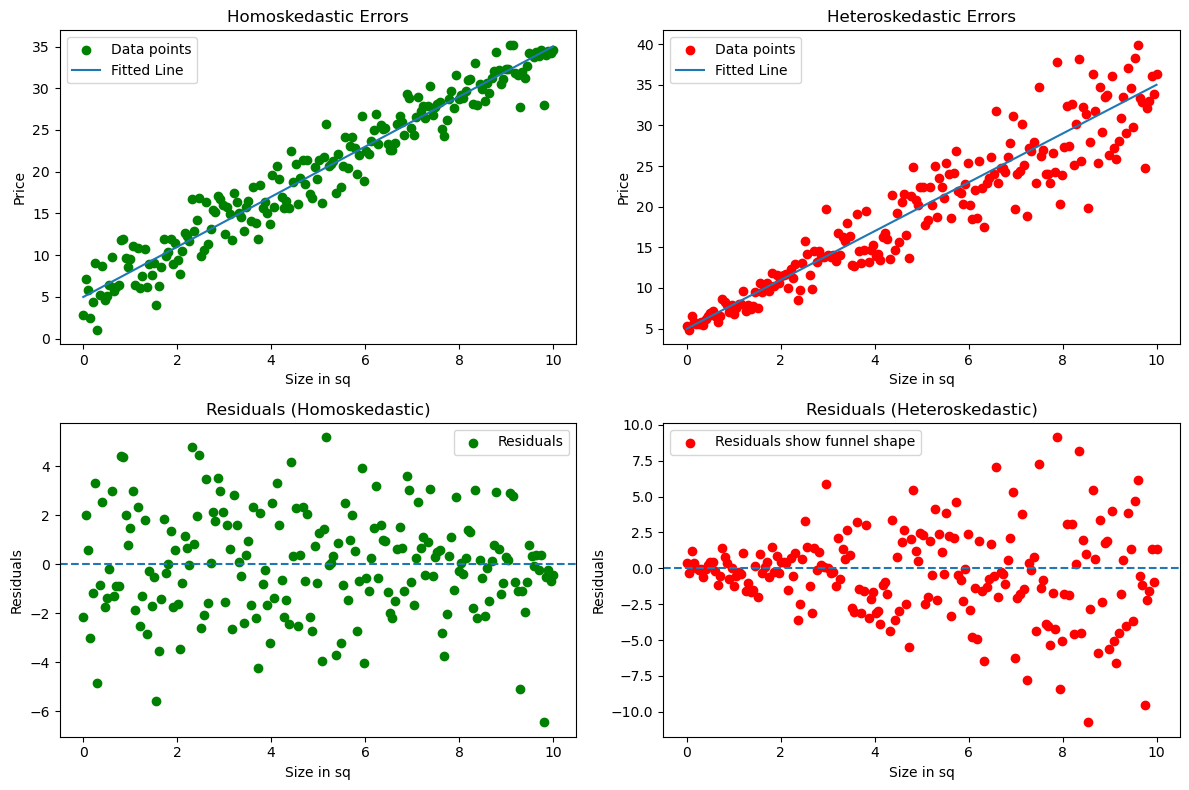

Variance of residuals by size bins (Homoskedastic): [np.float64(5.4399424118748225), np.float64(5.017954845277179), np.float64(5.336130995132632), np.float64(2.881998485442673), np.float64(3.349855160365643)]
Variance of residuals by size bins (Heteroskedastic): [np.float64(0.6852373803839601), np.float64(4.323434440791493), np.float64(7.468415207394403), np.float64(15.123670036514966), np.float64(17.376737976052013)]


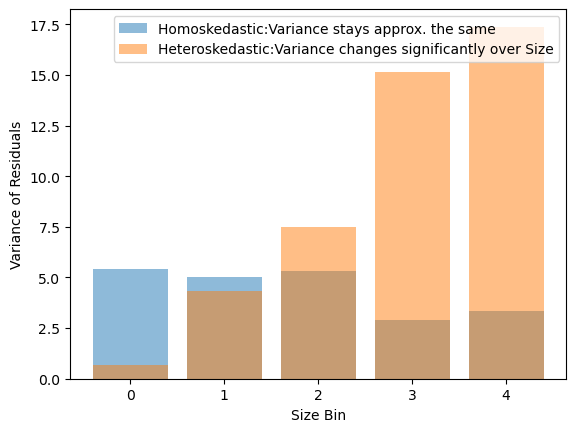

In [ ]:
np.random.seed(123) # for reproducibility of random numbers

n = 200 # Number of houses

size = np.linspace(0, 10, n)  # house sizes in sq

beta_0, beta_1 = 5, 3 # True relationship
price_true = beta_0 + beta_1 * size # true relationship between Price and Size

errors_homo = np.random.normal(0, 2, n) # Homoskedastic errors
price_homo = price_true + errors_homo # distorted relationship between Price and Size with homoskedastic errors

errors_hetero = np.random.normal(0, 0.5 + 0.5*size, n)  # Heteroskedastic errors: variance changes with size
price_hetero = price_true + errors_hetero # distorted relationship between Price and Size with heteroskedastic errors



# Plotting
fig, axes = plt.subplots(2, 2, figsize=(12,8))

# Homoskedastic data
axes[0,0].scatter(size, price_homo, color="green", label="Data points")
axes[0,0].plot(size, price_true, label="Fitted Line")
axes[0,0].set_title("Homoskedastic Errors")
axes[0,0].set_ylabel("Price")
axes[0,0].set_xlabel("Size in sq")
axes[0,0].legend()

# Heteroskedastic data
axes[0,1].scatter(size, price_hetero, color="red", label="Data points")
axes[0,1].plot(size, price_true, label="Fitted Line")
axes[0,1].set_title("Heteroskedastic Errors")
axes[0,1].set_ylabel("Price")
axes[0,1].set_xlabel("Size in sq")
axes[0,1].legend()


# Residuals
res_homo = price_homo - price_true 
res_hetero = price_hetero - price_true

# Residuals homoskedastic
axes[1,0].scatter(size, res_homo, color="green", label="Residuals")
axes[1,0].axhline(0, linestyle="--")
axes[1,0].set_title("Residuals (Homoskedastic)")
axes[1,0].set_ylabel("Residuals")
axes[1,0].set_xlabel("Size in sq")
axes[1,0].legend()

# Residuals heteroskedastic
axes[1,1].scatter(size, res_hetero, color="red", label="Residuals show funnel shape")
axes[1,1].axhline(0, linestyle="--")
axes[1,1].set_title("Residuals (Heteroskedastic)")
axes[1,1].set_ylabel("Residuals")
axes[1,1].set_xlabel("Size in sq")
axes[1,1].legend()

plt.tight_layout()
plt.show()


bins = 5 # Number of bins
bin_edges = np.linspace(min(size), max(size), bins+1) # array([ 0.,  2.,  4.,  6.,  8., 10.]) for size=np.linspace(0,10,n)
# | Bin | Size Range |
# | --- | ---------- |
# | 1   | 0 – 2      |
# | 2   | 2 – 4      |
# | 3   | 4 – 6      |
# | 4   | 6 – 8      |
# | 5   | 8 – 10     |

#print(list(range(len(bin_edges)-1)))
#print(size)
#print((size >= bin_edges[0]) & (size < bin_edges[0+1]),"\n")
#print((size >= bin_edges[1]) & (size < bin_edges[1+1]),"\n")

def residual_var_by_bin(residuals, size, bin_edges):
    var_list = []
    for i in range(len(bin_edges)-1): # go through every size interval by iterating over [0, 1, 2, 3, 4]
        mask = (size >= bin_edges[i]) & (size < bin_edges[i+1]) # check which house sizes are between the Size Range of Bin i
        var_bin = np.var(residuals[mask]) # np.var(res_homo[mask]) -> computes variance of Residuals of houses in specific Size range
        var_list.append(var_bin) # adds that variance to the list
    return var_list

# Compute variance per bin
var_homo = residual_var_by_bin(res_homo, size, bin_edges)
var_hetero = residual_var_by_bin(res_hetero, size, bin_edges)

print("Variance of residuals by size bins (Homoskedastic):", var_homo)
print("Variance of residuals by size bins (Heteroskedastic):", var_hetero)



plt.bar(range(bins), var_homo, alpha=0.5, label="Homoskedastic:Variance stays approx. the same")
plt.bar(range(bins), var_hetero, alpha=0.5, label="Heteroskedastic:Variance changes significantly over Size")
plt.xlabel("Size Bin")
plt.ylabel("Variance of Residuals")
plt.legend(loc=0)
plt.show()

### Normality of errors


Normality of Errors means that the residuals (errors) of the regression model are normally distributed around zero.

- In other words, most errors are small, and large positive or negative errors are rare, forming a bell-shaped distribution.
- This assumption does not affect the estimates of the coefficients $\hat{\beta_0}$ and $\hat{\beta_1}$ but it is important for statistical inference (e.g., confidence intervals and hypothesis tests).
- It is usually checked using a Q–Q plot or a histogram of residuals.

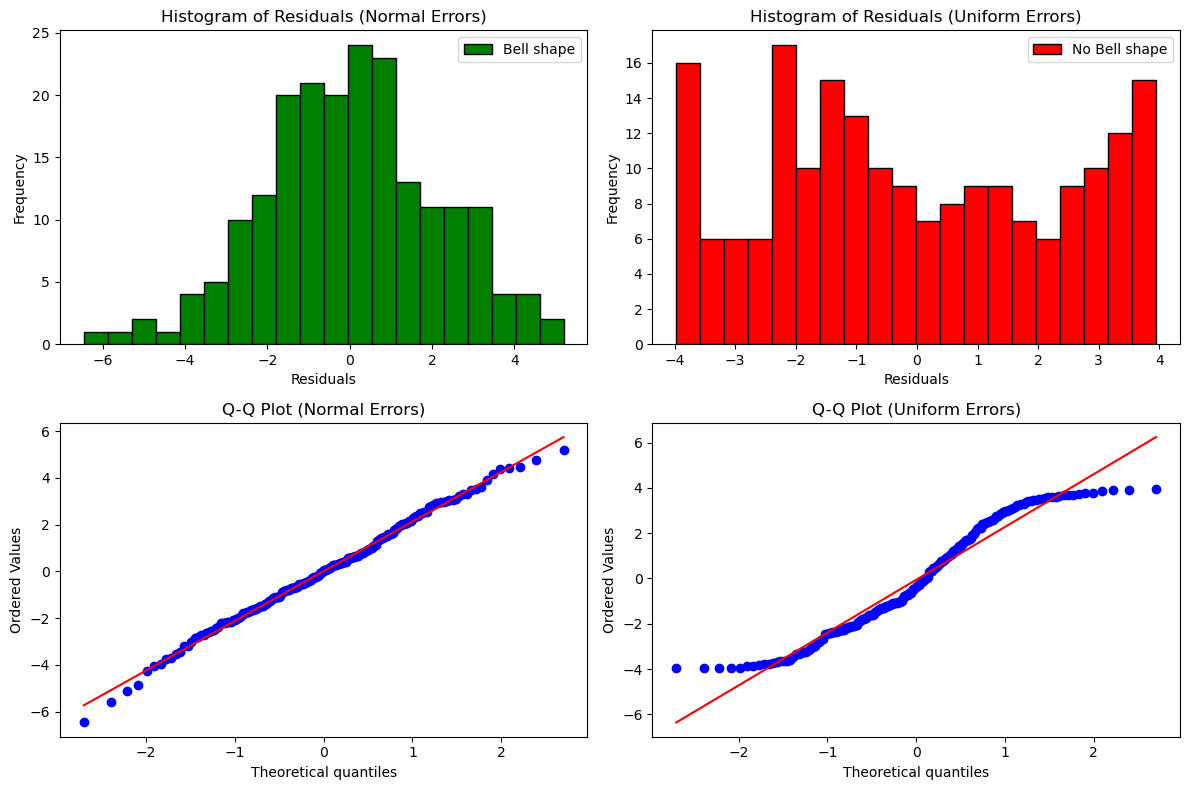

In [ ]:
np.random.seed(123)

n = 200 # number of houses

size = np.linspace(0, 10, n) # house sizes in square meters

beta_0, beta_1 = 5, 3 # true coefficients
price_true = beta_0 + beta_1 * size # true relationship between Price and Size


errors_normal = np.random.normal(0, 2, n) # Normal distributed errors
price_normal = price_true + errors_normal # distorted relationship between Price and Size using normal distributed errors

errors_uniform = np.random.uniform(-4, 4, n) # Uniform distributed errors
price_uniform = price_true + errors_uniform # distorted relationship between Price and Size using uniformly distributed errors


# Residuals
res_normal = price_normal - price_true # errors = price - predicted_price
res_uniform = price_uniform - price_true


# Plot
fig, axes = plt.subplots(2, 2, figsize=(12,8))

# Histogram (Normal)
axes[0,0].hist(res_normal, bins=20, color="green", edgecolor="black",label="Bell shape")
axes[0,0].set_title("Histogram of Residuals (Normal Errors)")
axes[0,0].set_xlabel("Residuals")
axes[0,0].set_ylabel("Frequency")
axes[0,0].legend()

# Histogram (Uniform)
axes[0,1].hist(res_uniform, bins=20, color="red", edgecolor="black",label="No Bell shape")
axes[0,1].set_title("Histogram of Residuals (Uniform Errors)")
axes[0,1].set_xlabel("Residuals")
axes[0,1].set_ylabel("Frequency")
axes[0,1].legend()


# QQ Plot (Normal)
stats.probplot(res_normal, dist="norm", plot=axes[1,0])
axes[1,0].set_title("Q-Q Plot (Normal Errors)")


# QQ Plot (Uniform)
stats.probplot(res_uniform, dist="norm", plot=axes[1,1])
axes[1,1].set_title("Q-Q Plot (Uniform Errors)")


plt.tight_layout()
plt.show()

### No Extreme Outliers

No Extreme Outliers means that there should be no observations that are extremely far from the rest of the data and strongly influence the regression line.

- Such outliers can pull the fitted line toward them, which can distort the estimated coefficients $\hat{\beta_0}$ and $\hat{\beta_1}$.
- They can also affect statistical inference, leading to misleading conclusions.
- This assumption is typically checked using boxplots, scatterplots, or residuals vs. fitted plots to identify unusually large residuals or extreme data points.

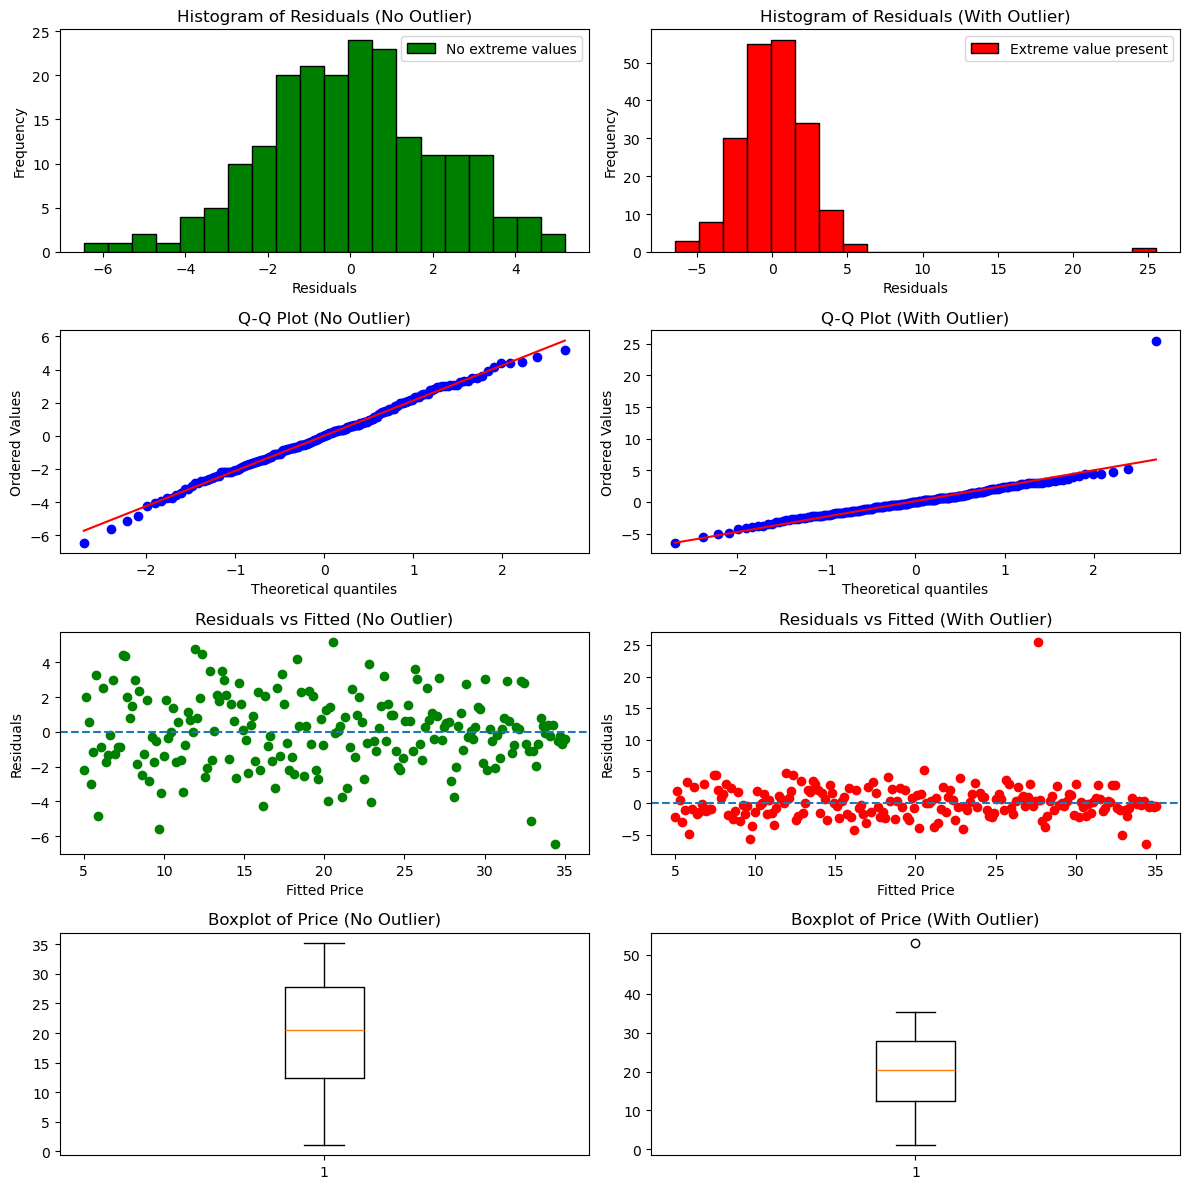

In [ ]:
np.random.seed(123) # for reproducibility of random numbers

n = 200 # number of houses

size = np.linspace(0, 10, n) # house sizes in square meters

beta_0, beta_1 = 5, 3 # true coefficients
price_true = beta_0 + beta_1 * size # true relationship between Price and Size


errors_normal = np.random.normal(0, 2, n) # Normal distributed errors
price_normal = price_true + errors_normal # distorted relationship between Price and Size


# Create dataset with an extreme outlier
price_outlier = price_normal.copy()
price_outlier[150] += 25 # add outlier at position 150 and add 25 on top of it


# Residuals
res_normal = price_normal - price_true
res_outlier = price_outlier - price_true


# Plot
fig, axes = plt.subplots(4, 2, figsize=(12,12))



# Histograms
axes[0,0].hist(res_normal, bins=20, color="green", edgecolor="black", label="No extreme values")
axes[0,0].set_title("Histogram of Residuals (No Outlier)")
axes[0,0].set_xlabel("Residuals")
axes[0,0].set_ylabel("Frequency")
axes[0,0].legend()

axes[0,1].hist(res_outlier, bins=20, color="red", edgecolor="black", label="Extreme value present")
axes[0,1].set_title("Histogram of Residuals (With Outlier)")
axes[0,1].set_xlabel("Residuals")
axes[0,1].set_ylabel("Frequency")
axes[0,1].legend()


# Q-Q plots
stats.probplot(res_normal, dist="norm", plot=axes[1,0])
axes[1,0].set_title("Q-Q Plot (No Outlier)")

stats.probplot(res_outlier, dist="norm", plot=axes[1,1])
axes[1,1].set_title("Q-Q Plot (With Outlier)")



# Residuals vs Fitted
axes[2,0].scatter(price_true, res_normal, color="green")
axes[2,0].axhline(0, linestyle="--")
axes[2,0].set_title("Residuals vs Fitted (No Outlier)")
axes[2,0].set_xlabel("Fitted Price")
axes[2,0].set_ylabel("Residuals")

axes[2,1].scatter(price_true, res_outlier, color="red")
axes[2,1].axhline(0, linestyle="--")
axes[2,1].set_title("Residuals vs Fitted (With Outlier)")
axes[2,1].set_xlabel("Fitted Price")
axes[2,1].set_ylabel("Residuals")

axes[3,0].boxplot(price_normal)
axes[3,0].set_title("Boxplot of Price (No Outlier)")

axes[3,1].boxplot(price_outlier)
axes[3,1].set_title("Boxplot of Price (With Outlier)")


plt.tight_layout()
plt.show()

<a class="anchor" id="min"></a>
## 3. Core Minimization problem (Ordinary Least Squares)

#### Model

The simple linear regression model is

$$
\text{Price}_i = \beta_0 + \beta_1 \cdot \text{Size}_i + \varepsilon_i \hspace{2 mm} \text{ for each house }i \text{ and } \varepsilon_i \sim \mathcal{N}(0,\sigma^2)
$$

and the predited value using the estimates $\hat{\beta_0}$ and $\hat{\beta_1}$ for $\beta_0$ and $\beta_0$ is

$$
\widehat{\text{Price}_i} = \hat{\beta_0} + \hat{\beta_1} \cdot \text{Size}_i 
$$

#### Residuals

The residual is the difference between observed and predicted value:

$$
\begin{align}
\varepsilon_i &= \text{Price}_i - \widehat{\text{Price}_i} \\
\Leftrightarrow \varepsilon_i &= \text{Price}_i - (\hat{\beta_0} + \hat{\beta_1} \cdot \text{Size}_i) \\
\Leftrightarrow \varepsilon_i &= \text{Price}_i - \hat{\beta_0} - \hat{\beta_1} \cdot \text{Size}_i
\end{align}
$$


#### Ordinary Least squares (OLS)

Simple linear regression estimates $\beta_0$ and $\beta_1$ by solving

$$
\min_{\beta_0,\beta_1} \sum_{i=1}^n \varepsilon_i^2 = \min_{\beta_0,\beta_1} \sum_{i=1}^n (\text{Price}_i - \hat{\beta_0} - \hat{\beta_1} \cdot \text{Size}_i)^2  
$$

This means:

- Compute the squared difference between actual Price of a house denoted as $\text{Price}_i$ and the predicted Price denoted as $\widehat{\text{Price}_i}$
- Sum these squared errors over all $n$ houses.
- Choose $\beta_0$ and $\beta_1$ that make this sum as small as possible and label them as $\hat{\beta_0}$ and $\hat{\beta_1}$.

Note: The Objective Function $\sum_{i=1}^n (\text{Price}_i - \hat{\beta_0} - \hat{\beta_1} \cdot \text{Size}_i)^2$ is called **Sum of squared errors** or short **SSE**


#### Resulting OLS Estimates

Solving the minimization yields:

$$
\hat{\beta_1} = \frac{\sum_{i=1}^n (\text{Size}_i - \overline{\text{Size}})(\text{Price}_i - \overline{\text{Price}})}{\sum_{i=1}^n (\text{Size}_i - \overline{\text{Size}})^2} 

\\[5mm]
\hat{\beta_0} =  \overline{\text{Price}} - \hat{\beta_1} \cdot \overline{\text{Size}}
$$

- $\overline{\text{Size}}$ is the mean of all values for the independent variable **Size**
- $\overline{\text{Price}}$ is the mean of all values for the dependent variable **Price**


&#128204; Simple linear regression finds the line that minimizes the sum of squared residuals between observed and predicted values.

In [341]:
# Import LinearRegression libraries from sklearn 
from sklearn.linear_model import LinearRegression

Real intercept 3 and slope 2 compared to estimated intercept -8.221271416202683 and estimated slope 2.013342737102346
The size variable has shape (100,) wich is one diemensional but LinearRegression.fit() requires 2 dimensions as (100, 1)
Manually estimated intercept -8.22 and slope 2.01 compared to model estimates of intercept -8.22 and slope 2.01


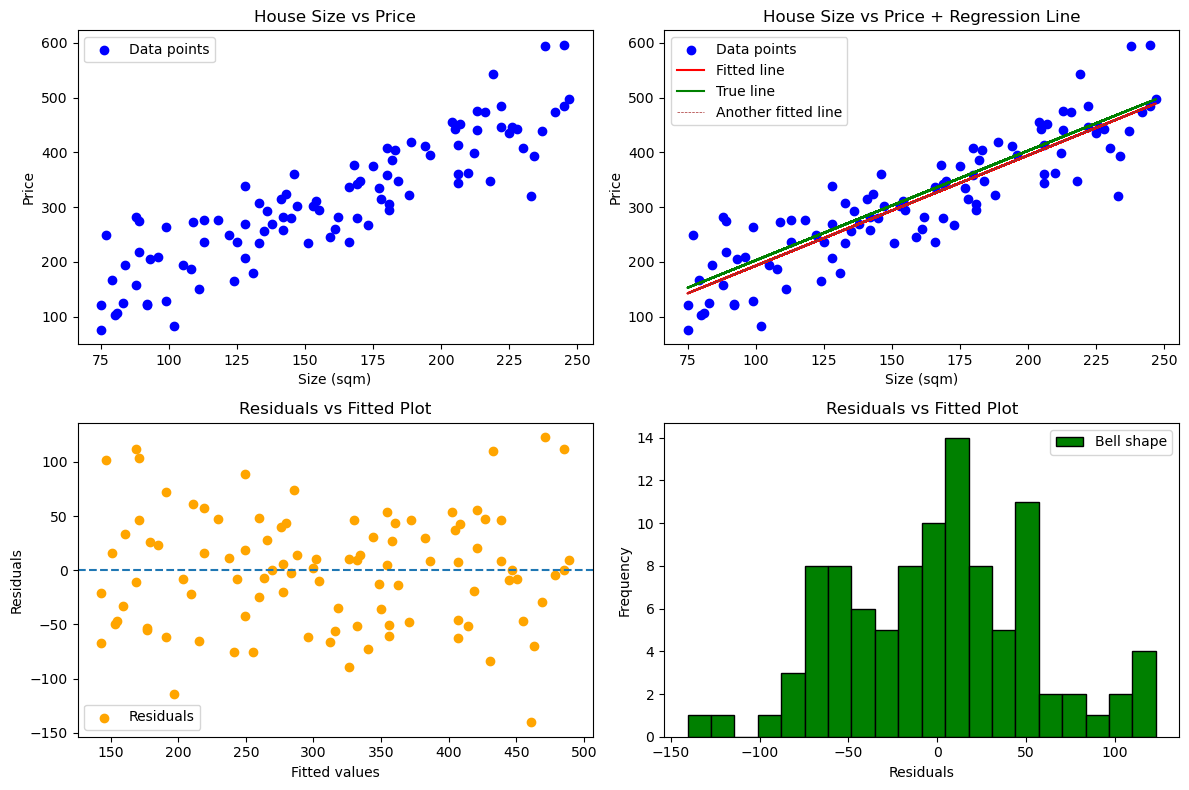

In [378]:
# Generate data according to assumptions

np.random.seed(100) # for reproducibility of random numbers

n = 100 # number of houses

size = np.random.randint(75,250,n) # house sizes in square meters

beta_0, beta_1 = 3, 2 # true coefficients

true_price = beta_0 + beta_1 * size # true relationship between Price and Size

errors = np.random.normal(loc=0,scale=50,size=n) # normally distributed and independent errors

price = true_price + errors # distorted and linear relationship between Price and Size

# Plot data
fig, axes = plt.subplots(nrows=2,ncols=2,figsize=(12,8))
axes[0,0].scatter(size, price, color='blue', label='Data points')
axes[0,0].set_title("House Size vs Price")
axes[0,0].set_xlabel("Size (sqm)")
axes[0,0].set_ylabel("Price")
axes[0,0].legend()

# Train model manually
mean_size, mean_price = np.mean(size), np.mean(price) # compute mean of Sizes and Prices
numerator = np.sum((size - mean_size)*(price - mean_price)) 
denominator = np.sum((size - mean_size)**2)
beta_1_hat = numerator / denominator # estimate slop
beta_0_hat = mean_price - beta_1_hat * mean_size # estimate intercept
print(f"Real intercept {beta_0} and slope {beta_1} compared to estimated intercept {beta_0_hat} and estimated slope {beta_1_hat}")
price_hat = beta_0_hat + beta_1_hat * size # make predictions for already seen houses
residuals = price - price_hat # errors = y - y_hat


# Plot Regression line
axes[0,1].scatter(size, price, color='blue', label='Data points')
axes[0,1].plot(size,price_hat,color="red",label="Fitted line")
axes[0,1].plot(size,true_price,color="green",label="True line")
axes[0,1].set_title("House Size vs Price + Regression Line")
axes[0,1].set_xlabel("Size (sqm)")
axes[0,1].set_ylabel("Price")
axes[0,1].legend()

# Residuals vs Fitted Plot
axes[1,0].scatter(price_hat, residuals, color='orange', label='Residuals')
axes[1,0].axhline(0, linestyle="--")
axes[1,0].set_title("Residuals vs Fitted Plot")
axes[1,0].set_xlabel("Fitted values")
axes[1,0].set_ylabel("Residuals")
axes[1,0].legend()


# Histogram of Residuals
axes[1,1].hist(residuals, bins=20, color="green", edgecolor="black",label="Bell shape")
axes[1,1].set_title("Residuals vs Fitted Plot")
axes[1,1].set_xlabel("Residuals")
axes[1,1].set_ylabel("Frequency")
axes[1,1].legend()


# Train model via LinearRegression library and compare
print(f"The size variable has shape {size.shape} wich is one diemensional but LinearRegression.fit() requires 2 dimensions as {size.reshape(-1,1).shape}")
X = size.reshape(-1,1) # reshape size into having 100 rows and 1 column
model = LinearRegression().fit(X, price) # train the model
print(f"Manually estimated intercept {beta_0_hat:.2f} and slope {beta_1_hat:.2f} compared to model estimates of intercept {model.intercept_:.2f} and slope {model.coef_[0]:.2f}")

axes[0,1].plot(size,model.predict(X),color="brown",label="Another fitted line",linewidth=0.5,linestyle='dashed')
axes[0,1].legend()

plt.tight_layout()
plt.show()

<a class="anchor" id="min"></a>
## 4. Model Quality
